### OPTIMIZING PUBLIC TRANSIT OPERATIONS
##### An Exploratory Data Analysis of public transportation
##### MetroMove Transit Solutions is a public transportation service provider operating in multiple cities.

###### I will be using EDA to manage and analyze thousands of daily trips taken via buses, trains, ferries, and trams, so as to improve passenger/customers' experience and optimize operations.

###### Import Libs for this Analysis

In [206]:
#### import libraries


import numpy as np
import pandas as pd  ###data preprocessing
import matplotlib.pyplot as plt # Data Visualization
import seaborn as sns    ##   Data Visaulization
from collections import Counter   ### Counting
import missingno as msno ### Missing Data - Data Visulation


In [207]:
#### Locate the file path and Load dataset into a pandas DataFrame

Data_Trans = 'Public_Transport_Trips_EDA1.csv'

df = pd.read_csv(Data_Trans)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 1,000 rows × 12 columns


##### With the data MetroMove has, I will be analyzing insights into * Trip Performance,  *Passenger Behavior, *Fare Patterns. With the use and process of EDA i will clean, explore, and summarize their trip records to identify inefficiencies and patterns that can drive operational improvements and also to boost customers satisfactions.

In [208]:
#### lets look at what we are working with, lets see the first 5 rows

### Print top 5 Rows

df.head(5) 


,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [209]:
##### Dimensionality of the data, exploring the numbers of rows and column

df.shape ###12 columns with 1000 rows with the data

(1000, 12)

In [210]:
##### To examine the variable/names in the column and features of the data

df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [211]:
##### Investigate the data set for annomalies

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_ID                1000 non-null   object 
 1   Mode_of_Transport      1000 non-null   object 
 2   Departure_Station      1000 non-null   object 
 3   Arrival_Station        1000 non-null   object 
 4   Departure_Time         1000 non-null   object 
 5   Passenger_Count        900 non-null    float64
 6   Fare_Amount            900 non-null    float64
 7   Trip_Duration_Minutes  900 non-null    float64
 8   Trip_Date              1000 non-null   object 
 9   Day_of_Week            1000 non-null   object 
 10  Unnamed: 10            0 non-null      float64
 11  Unnamed: 11            299 non-null    object 
dtypes: float64(4), object(8)
memory usage: 93.9+ KB


##### I can observe that column with with no name(10) has blanks termed NaN, we also can see some missing values, in column 11, Passenger count, Fare Amount,Trip Duration Minutes also has some missing values

In [212]:
#### Numerical Statistical Analysis

df.describe()

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Unnamed: 10
count,900.000000,900.000000,900.000000,0.0
mean,49.154444,25.360742,94.270000,NaN
std,27.698270,14.464556,50.634982,NaN
min,1.000000,0.500576,5.000000,NaN
25%,25.000000,12.818196,49.750000,NaN
50%,48.000000,25.403856,97.500000,NaN
75%,72.000000,37.866623,138.000000,NaN
max,99.000000,49.945184,179.000000,NaN


##### For the column 10 with no figures i will be deleting the entire column because it is not useful to our data

In [213]:
#### Categorical Statistical Analysis

df.describe(include=["object", "bool"])

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Trip_Date,Day_of_Week,Unnamed: 11
count,1000,1000,1000,1000,1000,1000,1000,299
unique,1000,9,7,7,1000,42,7,2
top,TRIP1000,Bus,North Station,South Point,2024-01-01 22:39:00,2024-01-01,Sunday,F
freq,1,147,171,171,1,24,167,250


In [214]:
#### Investigating the Missing Values
null_vals = df.isnull().sum()
null_vals

Trip_ID                     0
Mode_of_Transport           0
Departure_Station           0
Arrival_Station             0
Departure_Time              0
Passenger_Count           100
Fare_Amount               100
Trip_Duration_Minutes     100
Trip_Date                   0
Day_of_Week                 0
Unnamed: 10              1000
Unnamed: 11               701
dtype: int64

##### I will be using some Central standard Deviation tendencies to fill in the missing values in some variables, i will be using the mean to fill numerical missing variables and using mode to fill discrete variables(Categorical variables).

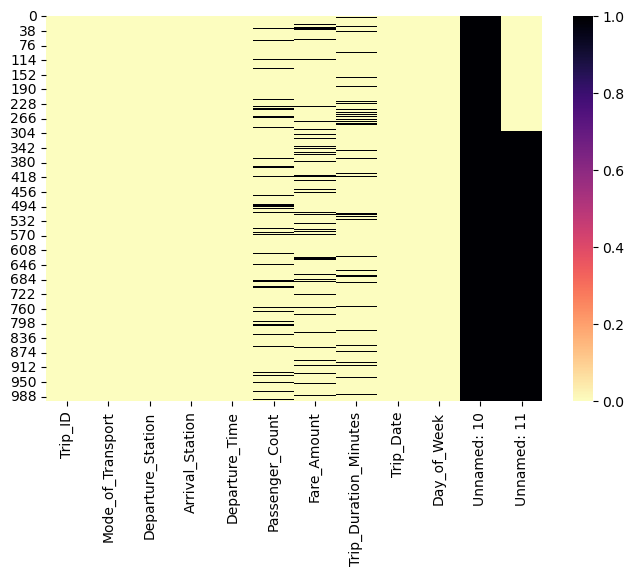

In [215]:
#### Visaualize the missing data
plt.figure(figsize = (8,5))
sns.heatmap(df.isnull(), cbar=True, cmap= "magma_r");

In [216]:
##### To display the location of the missing data set exist


df[df.isnull().any(axis=1)]   #### this is not gonna affect our analysis so we will drop it

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F
...,...,...,...,...,...,...,...,...,...,...,...,...
995,TRIP0996,train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,FERRY,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN


In [199]:
df.dropna(inplace=True)   ### to permanently remove it from the data

In [217]:
df.isnull().sum()

Trip_ID                     0
Mode_of_Transport           0
Departure_Station           0
Arrival_Station             0
Departure_Time              0
Passenger_Count           100
Fare_Amount               100
Trip_Duration_Minutes     100
Trip_Date                   0
Day_of_Week                 0
Unnamed: 10              1000
Unnamed: 11               701
dtype: int64

In [218]:
####### To drop column 10 because it is not useful for this analysis
df = df.drop(columns=['Unnamed: 10'])

df.head(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,F


In [219]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11'],
      dtype='object')

In [220]:
##### Convert the date data column into a pandas datetime object, so we can analyze the trips according to the Year, Months and Quarterly

df["Trip_Date"] = pd.to_datetime(df["Trip_Date"])
df.info()

##### Extract the Year, Month, Quater
df["year"] = df["Trip_Date"].dt.year
df["month"] = df["Trip_Date"].dt.month
df["month_name"] = df["Trip_Date"].dt.month_name()
df["quarter"] = df["Trip_Date"].dt.quarter
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   object        
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 86.1+ KB


,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 11,year,month,month_name,quarter
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,F,2024,1,January,1
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,F,2024,1,January,1


###### Effective decision-making relies on

##### Understanding passenger usage patterns.

###### Evaluating the performance of different transport modes.

###### Analyzing how trip characteristics impact customer experience.

###### This project provides a real-world simulation by Requiring cleaning and preprocessing of raw data.

##### Encouraging pattern discovery through exploratory data analysis.

##### Developing skills in communicating data-driven insights.

In [232]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen'],
      dtype='object')

In [233]:
### I will be looking at the revenue generated using the Passenger_count and Fare_Amount, so we will create a column called rev_gen(Revenue Generated)

df["rev_gen"] = df["Passenger_Count"]*df["Fare_Amount"]

df.head(3)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 11,year,month,month_name,quarter,rev_gen
0,TRIP0001,Ferry,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,F,2024,1,January,1,91.216483
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,F,2024,1,January,1,950.975482
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,F,2024,1,January,1,NaN


#### I was able to create the revenue generated as regards to the customers that paid for the fares, i will be comparing teh mode of transportation as a categorical variable i will be using a countplots to see their relationship between each mode of transportation

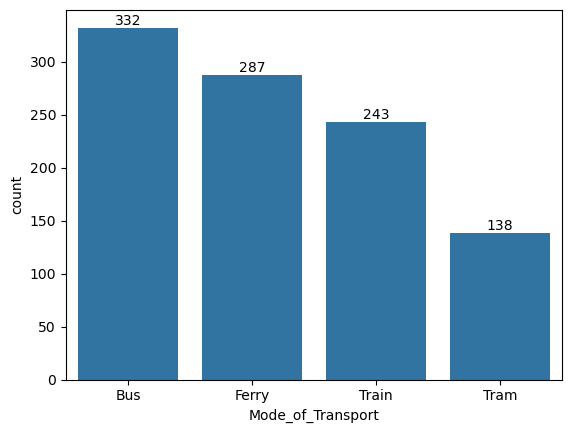

In [237]:
##### Categorical Visualization Analysis

### Relationship between each mode of Tansporation
ax = sns.countplot(x=df["Mode_of_Transport"], order=df["Mode_of_Transport"].value_counts(ascending=False).index)
values = df["Mode_of_Transport"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

##### I can observe that this gave a relationship, but i can see that we have same mode of transportation but its written in mixed aplhabet using big and small, so i will create a uniform writing style for each mode of transport to sum it all together.

In [235]:
##### To correct the spelling from FERRY and fErry to Ferry;  

df.loc[df["Mode_of_Transport"] == "FERRY", "Mode_of_Transport"] = "Ferry"
df.loc[df["Mode_of_Transport"] == "fErry", "Mode_of_Transport"] = "Ferry"

####Also to  correct the spelling from BUS and bus to Bus;

df.loc[df["Mode_of_Transport"] == "BUS", "Mode_of_Transport"] = "Bus"
df.loc[df["Mode_of_Transport"] == "bus", "Mode_of_Transport"] = "Bus"

#### Also to correct the spelling from train to Train; 
df.loc[df["Mode_of_Transport"] == "train", "Mode_of_Transport"] = "Train"

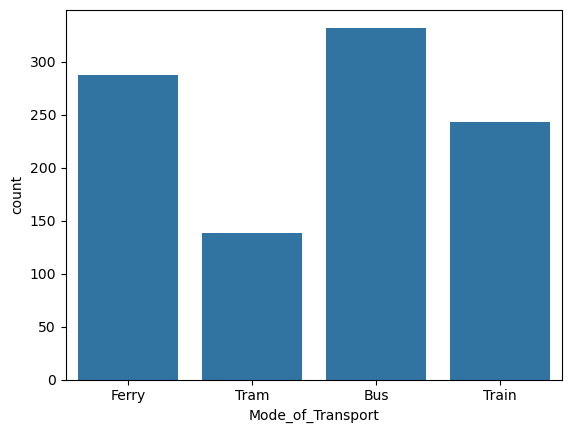

In [236]:
### Relationship between each mode of Tansporation (Corrected Version)
sns.countplot(x="Mode_of_Transport", data=df);

#### Based on my Observation after the correction, we could see the highest mode of transportation which is the Bus, then the Ferry, Train and the Tram has the lowest 

In [238]:
df["Mode_of_Transport"].value_counts()

Mode_of_Transport
Bus      332
Ferry    287
Train    243
Tram     138
Name: count, dtype: int64

In [239]:
df["Unnamed: 11"].value_counts()

Unnamed: 11
F    250
T     49
Name: count, dtype: int64

In [240]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen'],
      dtype='object')

In [242]:
df.head(5)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 11,year,month,month_name,quarter,rev_gen
0,TRIP0001,Ferry,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,F,2024,1,January,1,91.216483
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,F,2024,1,January,1,950.975482
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,F,2024,1,January,1,NaN
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,F,2024,1,January,1,101.722157
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,F,2024,1,January,1,NaN


In [230]:
###### I want to analyse using bivariante analysis of passenger count and mode of transport, day of the week, Revenue Generated

In [243]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen'],
      dtype='object')

''

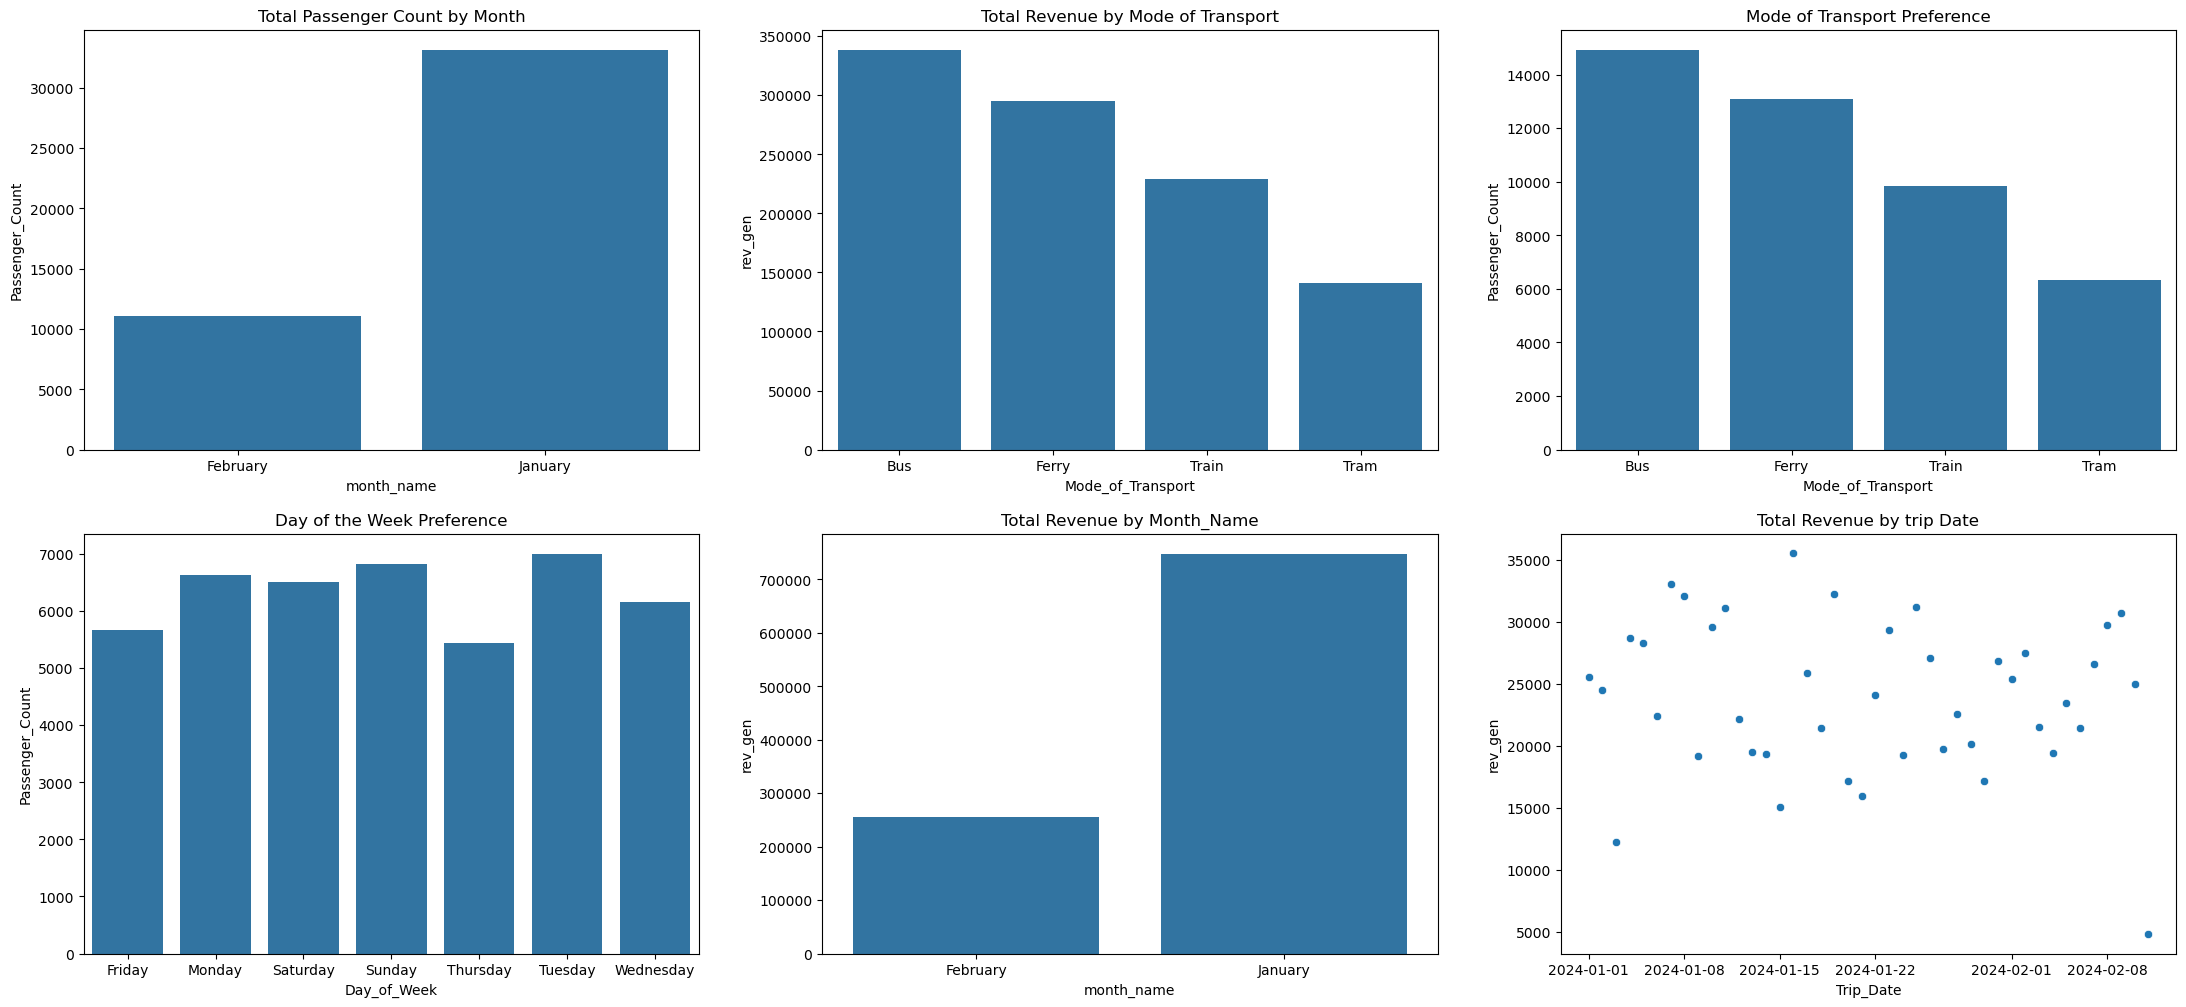

In [273]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(27,12))   #### we use this to do subplots we have 2rows and 3 column i.e 6 boxes

month_passenger = df.groupby("month_name")["Passenger_Count"].sum().reset_index()
sns.barplot(y='Passenger_Count', data=month_passenger, x='month_name', ax=axs[0,0])
axs[0,0].set_title("Total Passenger Count by Month")

;

rev_transport = df.groupby("Mode_of_Transport")["rev_gen"].sum().reset_index()
sns.barplot(x='Mode_of_Transport', data=rev_transport, y='rev_gen', ax=axs[0,1])
axs[0,1].set_title("Total Revenue by Mode of Transport")

;

pass_transport = df.groupby("Mode_of_Transport")["Passenger_Count"].sum().reset_index()
sns.barplot(y='Passenger_Count', data=pass_transport, x='Mode_of_Transport', ax=axs[0,2])
axs[0,2].set_title("Mode of Transport Preference")

;

pass_week = df.groupby("Day_of_Week")["Passenger_Count"].sum().reset_index()
sns.barplot(y='Passenger_Count', data=pass_week, x='Day_of_Week', ax=axs[1,0])
axs[1,0].set_title("Day of the Week Preference")

;

rev_month = df.groupby("month_name")["rev_gen"].sum().reset_index()
sns.barplot(y='rev_gen', data=rev_month, x='month_name', ax=axs[1,1])
axs[1,1].set_title("Total Revenue by Month_Name")

;

trip_rev = df.groupby("Trip_Date")["rev_gen"].sum().reset_index()
sns.scatterplot(y='rev_gen', data=trip_rev, x='Trip_Date', ax=axs[1,2])
axs[1,2].set_title("Total Revenue by trip Date")

;

In [245]:
#### Categorize the fare trips time slots allocations, we have 5mins as the lowest and 179 as the highest mins spent on a trip
##### we have to categorize the time spent on the trip.

In [246]:
###### Group Trip_Duration_Minutes

#### Create a function for trip_duration_cat

def trip_durat_cat(x):
    if x <= 45:
        return "<=45 Short trip time"
    elif x <= 90:
        return "45-90 Normal trip time"
    elif x <= 135:
        return "90-135 Long trip time"
    else:
        return ">=136 Longer trip time"

        
### Apply function to the data
df["trip_durat_cat"] = df["Trip_Duration_Minutes"].apply(trip_durat_cat)
df.head(2)

        

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 11,year,month,month_name,quarter,rev_gen,trip_durat_cat
0,TRIP0001,Ferry,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,F,2024,1,January,1,91.216483,<=45 Short trip time
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,F,2024,1,January,1,950.975482,90-135 Long trip time


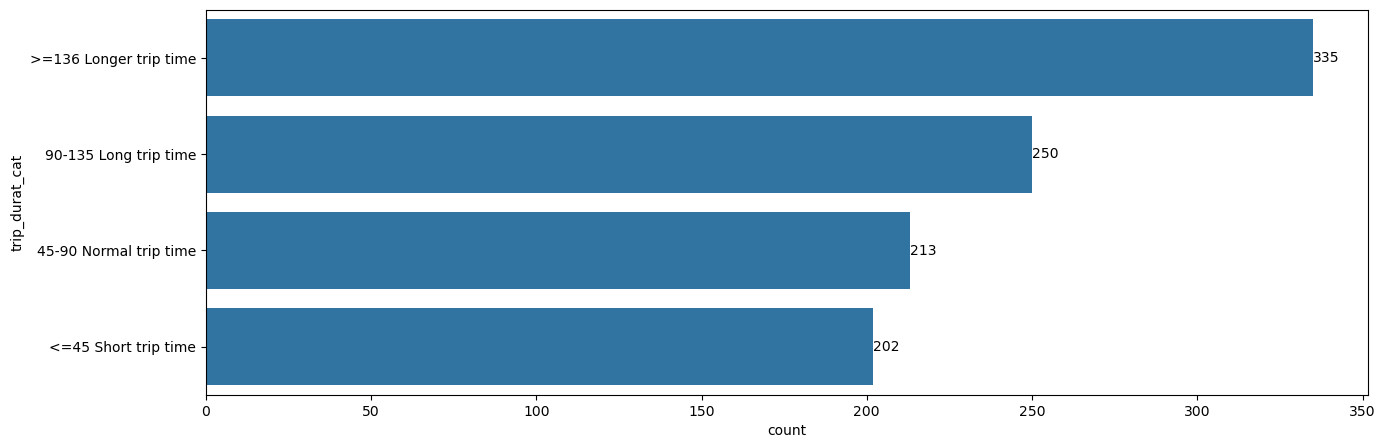

In [247]:
#### Total Passenger_count by Trip_Duration_Minutes,


plt.figure(figsize=(15,5))

ax = sns.countplot(y=df["trip_durat_cat"], order=df["trip_durat_cat"].value_counts(ascending=False).index)
values = df["trip_durat_cat"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

In [48]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen'],
      dtype='object')

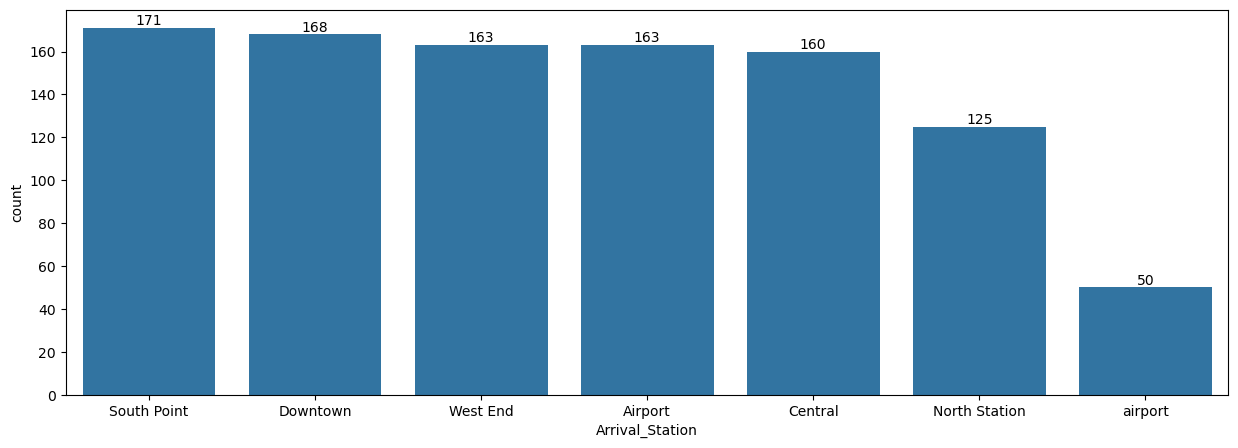

In [248]:
#####Total Trips by  Arrival station

plt.figure(figsize=(15,5))
ax = sns.countplot(x=df["Arrival_Station"], order=df["Arrival_Station"].value_counts(ascending=False).index)
values = df["Arrival_Station"].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values);

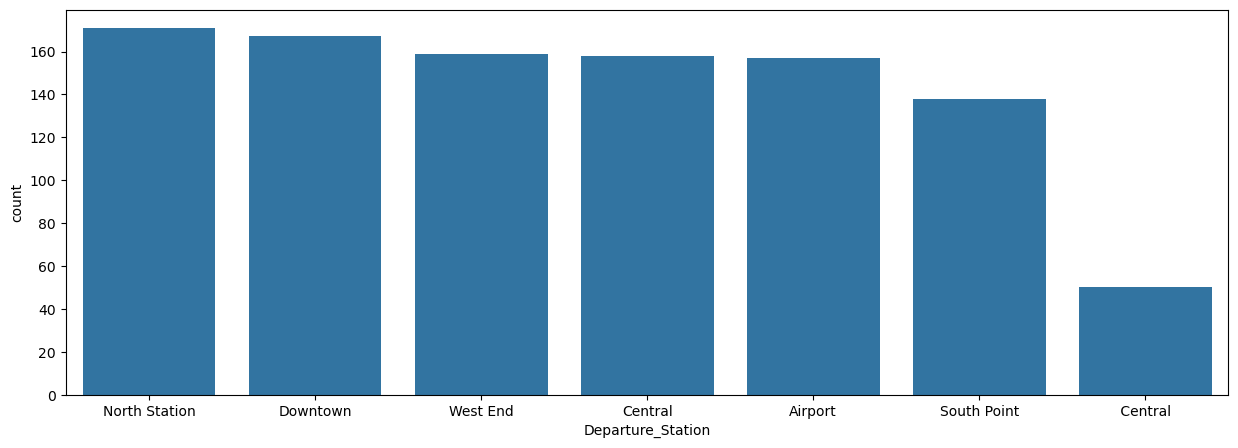

In [249]:
#####Total Trips by Departure station and Arrival station

plt.figure(figsize=(15,5))

topten = df["Departure_Station"].value_counts().head(10)

sns.countplot(x="Departure_Station", data=df, order=topten.index);

In [250]:
#### Total mode of transport by Trip_Duration_Minutes,

###### We will be looking at mode of transport so we will be comparing it against duration of trip and revenue generated

#### We will be using the function groupby

#### using melt to transpose the data




In [276]:
modurat = df.groupby("Mode_of_Transport")[["trip_durat_cat", "rev_gen"]].sum().reset_index()
modurat


,Mode_of_Transport,trip_durat_cat,rev_gen
0,Bus,>=136 Longer trip time90-135 Long trip time90-...,338650.900683
1,Ferry,<=45 Short trip time>=136 Longer trip time>=13...,294969.312744
2,Train,>=136 Longer trip time>=136 Longer trip time45...,228954.674470
3,Tram,90-135 Long trip time45-90 Normal trip time90-...,141085.622294


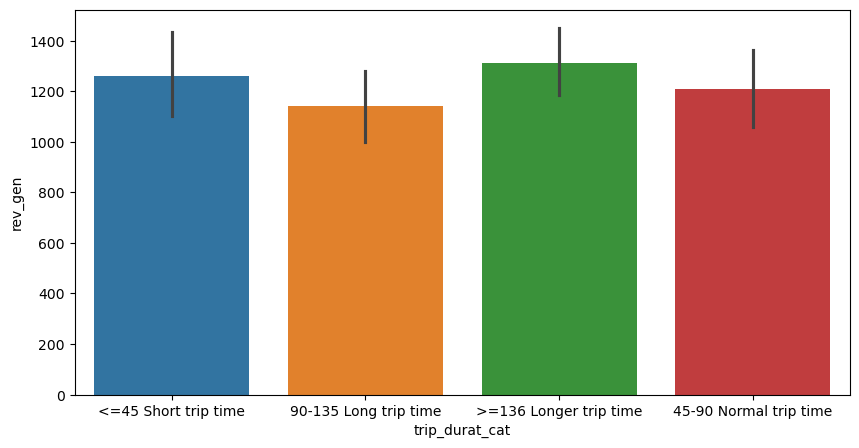

In [290]:
##### Revenue generated via duration spent on trip

plt.figure(figsize=(10,5))

sns.barplot(x="trip_durat_cat", y='rev_gen', data=df, hue="trip_durat_cat");



In [58]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen', 'trip_durat_cat'],
      dtype='object')

In [252]:

trip_rev = df.groupby("trip_durat_cat")[["rev_gen"]].sum().reset_index()
trip_rev


,trip_durat_cat,rev_gen
0,45-90 Normal trip time,199729.421779
1,90-135 Long trip time,233747.111544
2,<=45 Short trip time,206743.633063
3,>=136 Longer trip time,363440.343805


Text(0.5, 1.0, 'Total Revenue by Trip Duration')

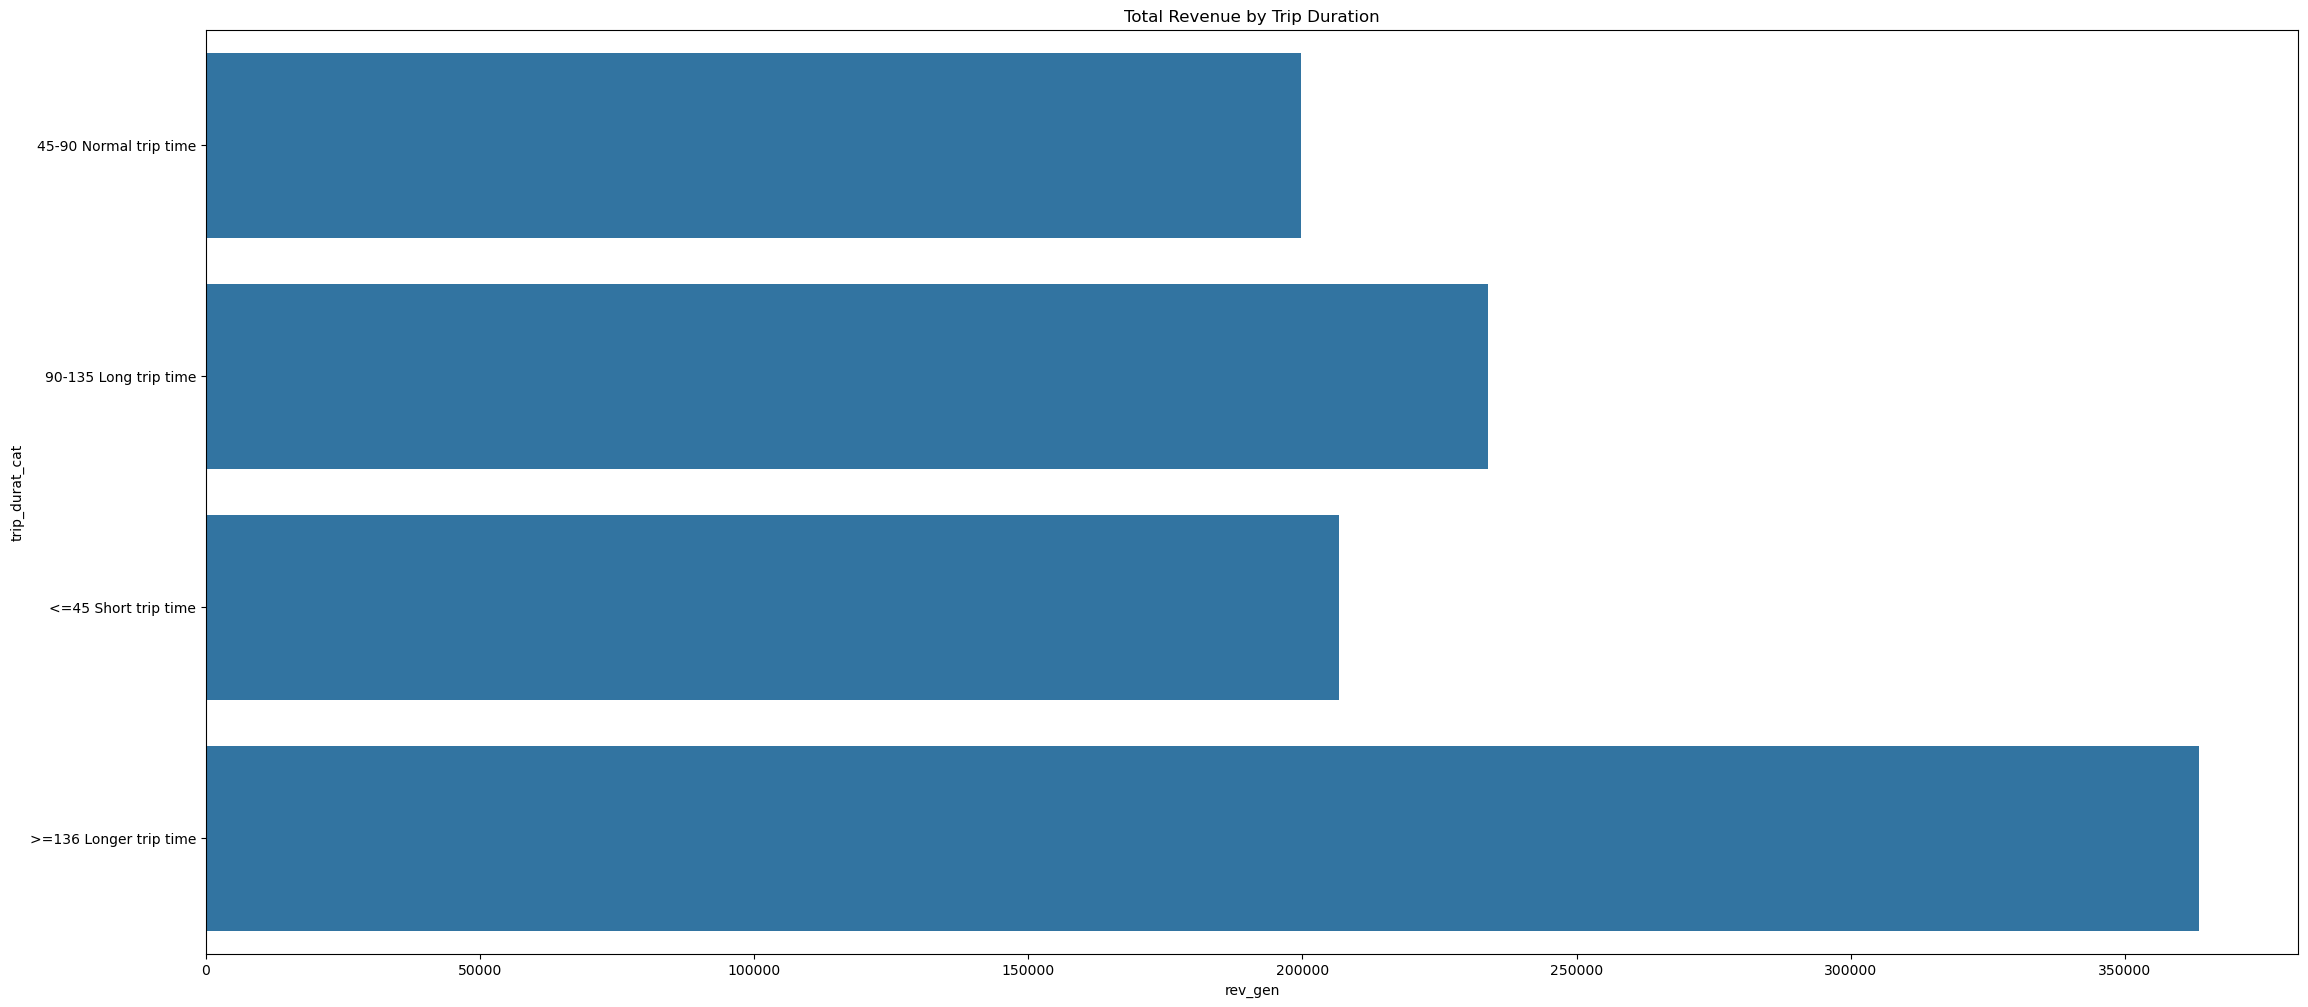

In [253]:
fig, ax = plt.subplots(figsize=(27,12))   #### we use this to do subplots we have 2rows and 3 column i.e 6 boxes

trip_rev = df.groupby("trip_durat_cat")["rev_gen"].sum().reset_index()
sns.barplot(y='trip_durat_cat', data=trip_rev, x='rev_gen')
values = df["rev_gen"].value_counts(ascending=False).values
ax.set_title("Total Revenue by Trip Duration")


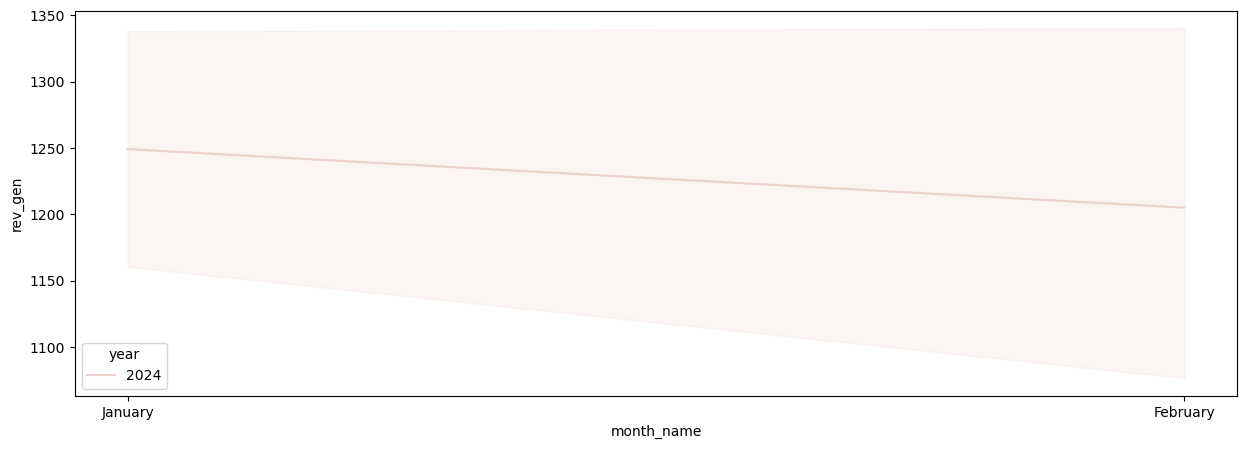

In [77]:
plt.figure(figsize=(15,5))
sns.lineplot(x='month_name', y='rev_gen', data=df, hue='year');

In [78]:
#### Using a Pivot Table

df.pivot_table(values='rev_gen', index='year', columns='month_name', aggfunc='sum')

month_name,February,January
year,,
2024,255446.462265,748214.047926


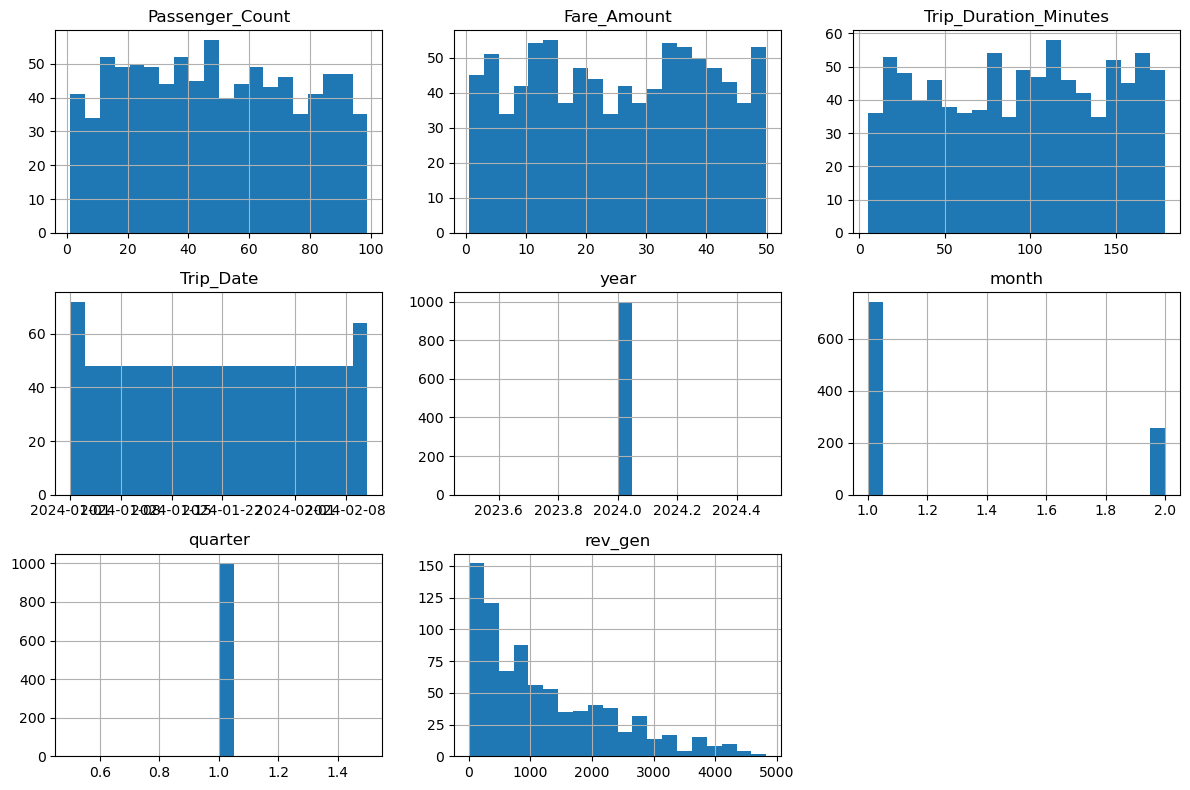

In [254]:
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


                       Passenger_Count  Fare_Amount  Trip_Duration_Minutes  \
Passenger_Count               1.000000     0.015250               0.021590   
Fare_Amount                   0.015250     1.000000              -0.046738   
Trip_Duration_Minutes         0.021590    -0.046738               1.000000   
month                        -0.036285     0.020737              -0.005246   
rev_gen                       0.655500     0.669072              -0.008460   

                          month   rev_gen  
Passenger_Count       -0.036285  0.655500  
Fare_Amount            0.020737  0.669072  
Trip_Duration_Minutes -0.005246 -0.008460  
month                  1.000000 -0.017765  
rev_gen               -0.017765  1.000000  


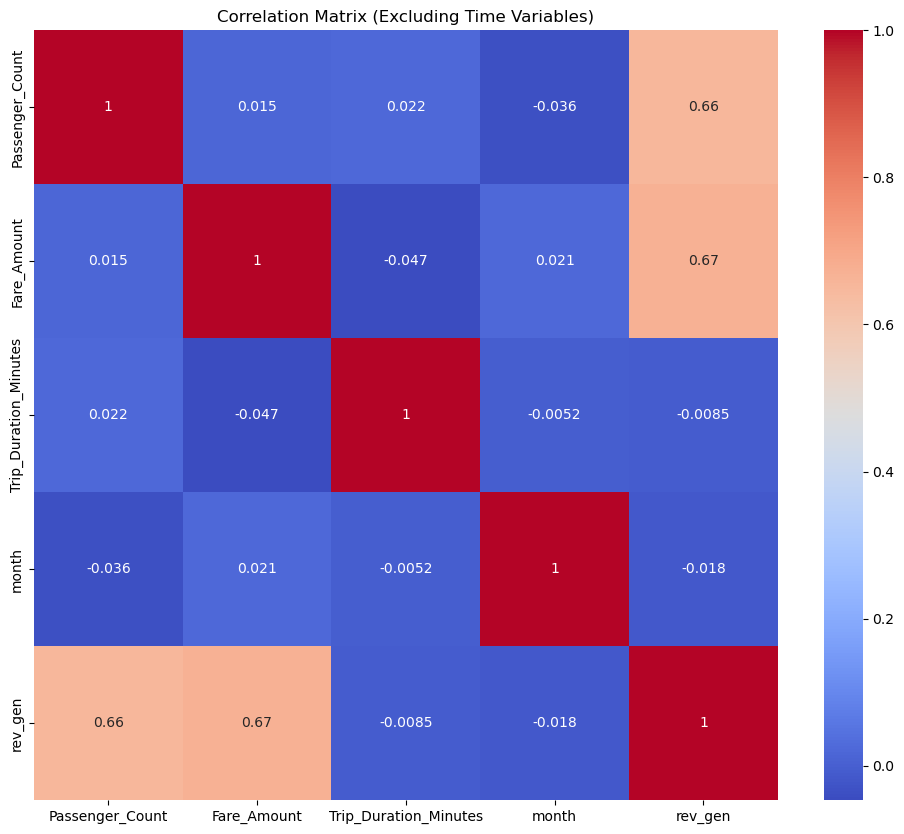

In [272]:
import numpy as np
# 1. List the columns you want to exclude
to_exclude = ['year', 'quarter']

# 2. Drop them and calculate correlation on the remaining numeric columns
cor = df.drop(columns=to_exclude).corr(numeric_only=True)
print()
print(cor)

# 3. Visualize
f, ax = plt.subplots(figsize=(12,10))
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Excluding Time Variables)")
plt.show()

In [259]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen', 'trip_durat_cat'],
      dtype='object')

In [260]:
####### To drop column 10 because it is not useful for this analysis
df = df.drop(columns=['Trip_ID'])

df.head(2)

,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 11,year,month,month_name,quarter,rev_gen,trip_durat_cat
0,Ferry,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,F,2024,1,January,1,91.216483,<=45 Short trip time
1,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,F,2024,1,January,1,950.975482,90-135 Long trip time


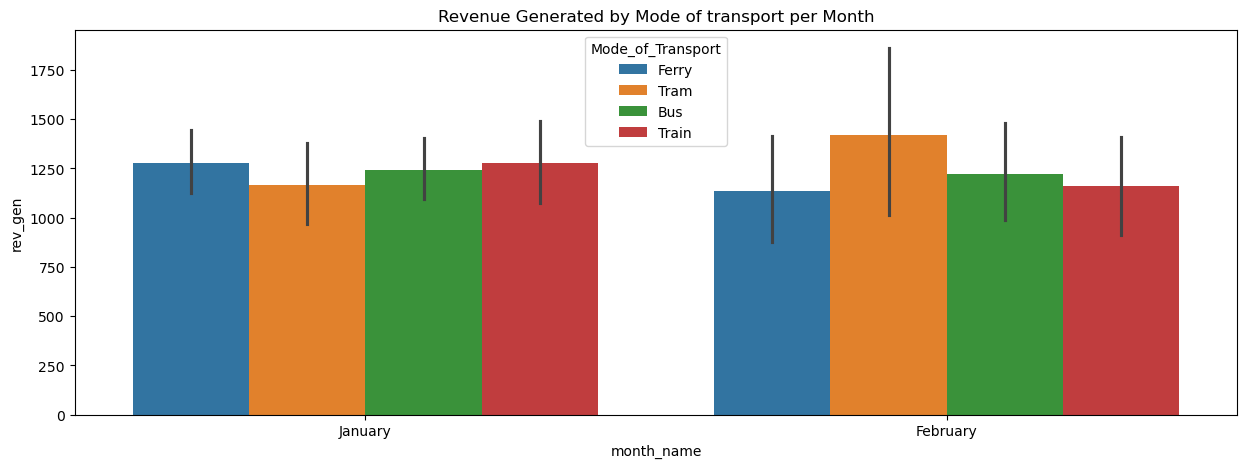

In [287]:
####### Using Multivariante to visualize the revenue generated on different mode of transport across each month

plt.figure(figsize=(15,5))

sns.barplot(x="month_name", y='rev_gen', data=df, hue="Mode_of_Transport")
plt.title("Revenue Generated by Mode of transport per Month");

In [282]:
df.columns

Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 11',
       'year', 'month', 'month_name', 'quarter', 'rev_gen', 'trip_durat_cat'],
      dtype='object')

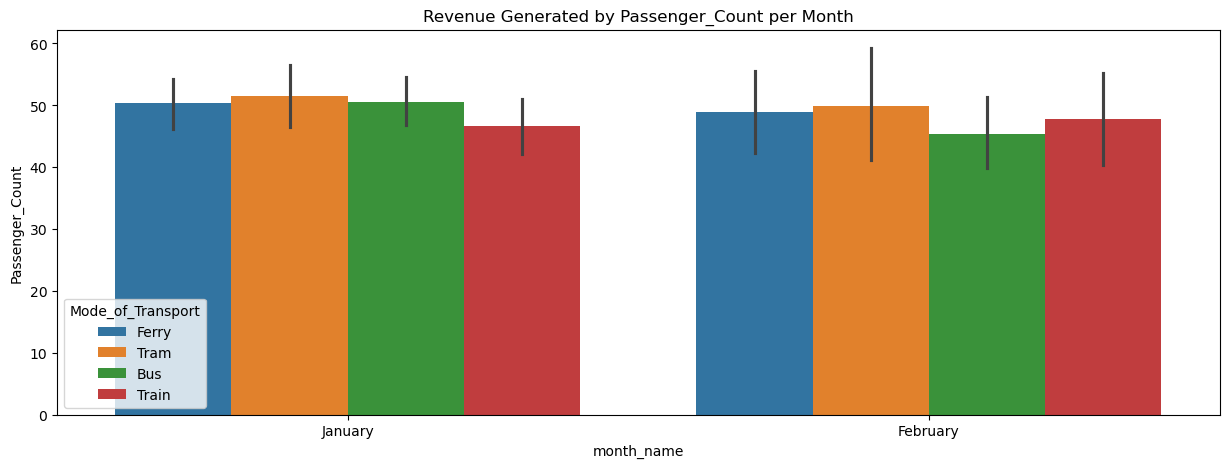

In [288]:
####### Using Multivariante to visualize the passenger count on different mode of transport across each month

plt.figure(figsize=(15,5))

sns.barplot(x="month_name", y='Passenger_Count', data=df, hue="Mode_of_Transport")
plt.title("Revenue Generated by Passenger_Count per Month");

C:\Users\mstel\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


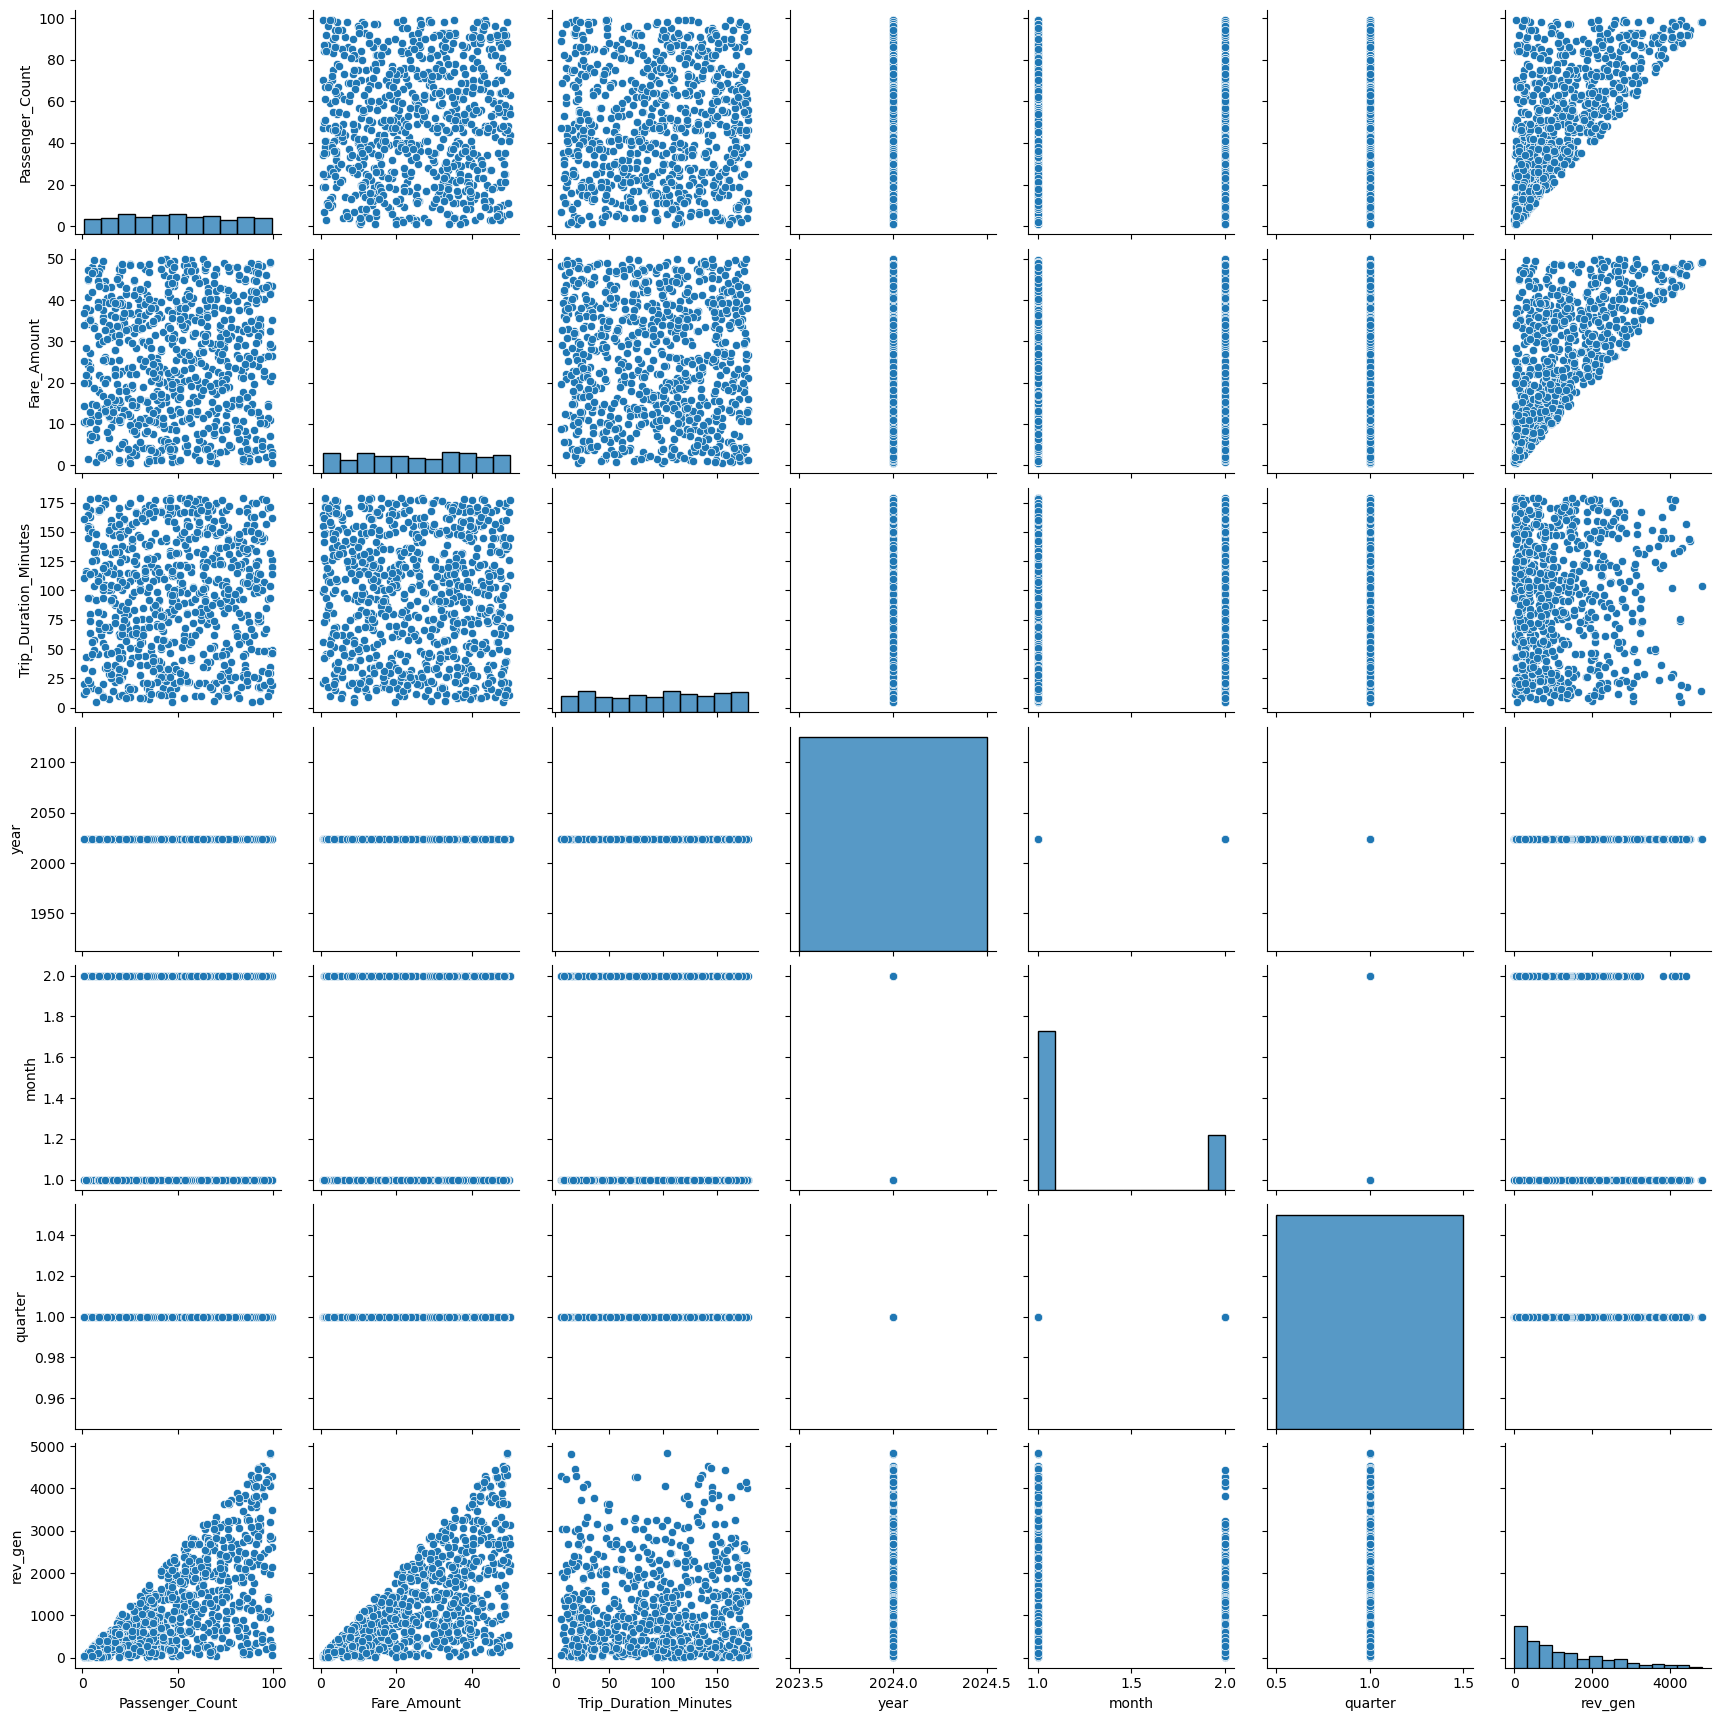

In [281]:
sns.pairplot(df, size=2.5)


In [280]:
import warnings